In [2]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Text processing
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# For word clouds
from wordcloud import WordCloud

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 2: Load the financial news dataset
# Note: Replace 'your_file_path.csv' with the actual path to your data file

# Try different possible file locations
import os

# Check common locations
possible_paths = [
    '../data/raw/fnspid_news.csv',
    'data/raw/fnspid_news.csv', 
    '../fnspid_news.csv',
    'fnspid_news.csv'
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Data loaded from: {path}")
        break

if df is None:
    print("Could not find data file. Please check the file path.")
    print("Current directory:", os.getcwd())
    print("Files in current directory:", os.listdir())
else:
    print(f"Data shape: {df.shape}")
    df.head()

Could not find data file. Please check the file path.
Current directory: C:\Users\HP\news-sentiment-analysis\notebooks
Files in current directory: ['.ipynb_checkpoints', '01_eda_news.ipynb', '__init__.py']


In [4]:
import os

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'
print("Files in data/raw folder:")
for file in os.listdir(data_path):
    if file.endswith('.csv'):
        print(f"  - {file}")

Files in data/raw folder:
  - raw_analyst_ratings.csv


In [5]:
# Cell 2: Load the actual data
import pandas as pd
import os

# Set the correct path
data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'
file_name = 'raw_analyst_ratings.csv'
full_path = os.path.join(data_path, file_name)

# Load the data
df = pd.read_csv(full_path)

print(f"Data loaded successfully!")
print(f"File: {file_name}")
print(f"Data shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Data loaded successfully!
File: raw_analyst_ratings.csv
Data shape: 1407328 rows × 6 columns

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
# Cell 2e: Quick preview
print("=== DATA PREVIEW ===")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

# If you have the expected columns
if 'headline' in df.columns:
    print(f"\nSample headlines:")
    for i in range(3):
        print(f"  {i+1}. {df['headline'].iloc[i][:100]}...")
        
if 'publisher' in df.columns:
    print(f"\nUnique publishers: {df['publisher'].nunique()}")
    
if 'date' in df.columns:
    print(f"Date column exists: {df['date'].dtype}")
    
if 'stock' in df.columns:
    print(f"Unique stocks: {df['stock'].nunique()}")

=== DATA PREVIEW ===
Total rows: 1,407,328
Total columns: 6

Sample headlines:
  1. Stocks That Hit 52-Week Highs On Friday...
  2. Stocks That Hit 52-Week Highs On Wednesday...
  3. 71 Biggest Movers From Friday...

Unique publishers: 1034
Date column exists: str
Unique stocks: 6204


In [7]:
# Cell 3: Basic data info
print("=== DATASET OVERVIEW ===")
print(f"Total articles: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n=== COLUMN INFO ===")
df.info()

print("\n=== FIRST 5 ROWS ===")
df.head()

print("\n=== LAST 5 ROWS ===")
df.tail()

=== DATASET OVERVIEW ===
Total articles: 1,407,328
Total columns: 6
Memory usage: 634.66 MB

=== COLUMN INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB

=== FIRST 5 ROWS ===

=== LAST 5 ROWS ===


,Unnamed: 0,headline,url,publisher,date,stock
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX
1407327,1413848,China Zenix Auto International Opens For Tradi...,https://www.benzinga.com/news/ipos/11/05/10789...,Allie Wickman,2011-05-12 00:00:00,ZX


=== HEADLINE STATISTICS ===
Mean length: 73.1 characters
Median length: 64.0 characters
Min length: 3
Max length: 512

Mean word count: 11.4 words
Median word count: 10.0 words

📝 Shortest headline (3 chars):
   SPY

📝 Longest headline (512 chars):
   JinkoSolar Tiger Pro Series Receives World's First IEC 61701 Ed. 3 (FDIS) Certification for Salt Mist Corrosion Standards JinkoSolar Holding Co., Ltd. (the "Company," or "JinkoSolar") (NYSE:JKS), one ...


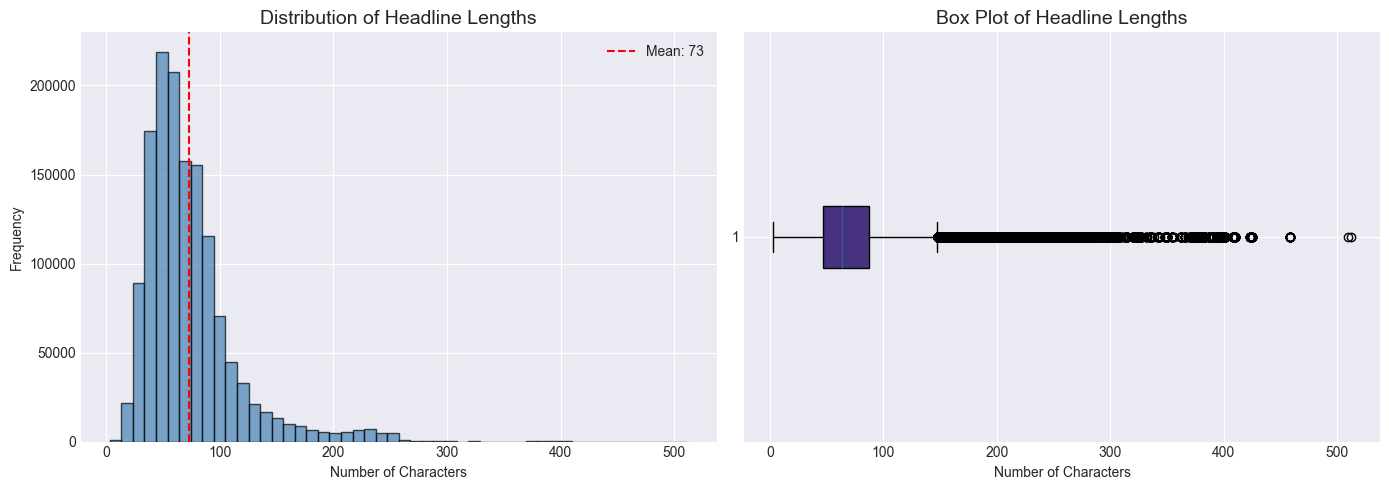

In [8]:
# Cell 4: Headline characteristics
# Calculate lengths
df['headline_length'] = df['headline'].str.len()
df['word_count'] = df['headline'].str.split().str.len()

print("=== HEADLINE STATISTICS ===")
print(f"Mean length: {df['headline_length'].mean():.1f} characters")
print(f"Median length: {df['headline_length'].median():.1f} characters")
print(f"Min length: {df['headline_length'].min()}")
print(f"Max length: {df['headline_length'].max()}")
print(f"\nMean word count: {df['word_count'].mean():.1f} words")
print(f"Median word count: {df['word_count'].median():.1f} words")

# Shortest and longest headlines
shortest_idx = df['headline_length'].idxmin()
longest_idx = df['headline_length'].idxmax()
print(f"\n📝 Shortest headline ({df['headline_length'].min()} chars):")
print(f"   {df.loc[shortest_idx, 'headline']}")
print(f"\n📝 Longest headline ({df['headline_length'].max()} chars):")
print(f"   {df.loc[longest_idx, 'headline'][:200]}...")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['headline_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Headline Lengths', fontsize=14)
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_length"].mean():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['headline_length'], vert=False, patch_artist=True)
axes[1].set_title('Box Plot of Headline Lengths', fontsize=14)
axes[1].set_xlabel('Number of Characters')

plt.tight_layout()
plt.show()

=== TOP 15 PUBLISHERS ===
 1. Paul Quintaro                             228,373 articles (16.2%)
 2. Lisa Levin                                186,979 articles (13.3%)
 3. Benzinga Newsdesk                         150,484 articles (10.7%)
 4. Charles Gross                              96,732 articles (6.9%)
 5. Monica Gerson                              82,380 articles (5.9%)
 6. Eddie Staley                               57,254 articles (4.1%)
 7. Hal Lindon                                 49,047 articles (3.5%)
 8. ETF Professor                              28,489 articles (2.0%)
 9. Juan Lopez                                 28,438 articles (2.0%)
10. Benzinga Staff                             28,114 articles (2.0%)
11. Vick Meyer                                 24,826 articles (1.8%)
12. webmaster                                  20,313 articles (1.4%)
13. Benzinga_Newsdesk                          19,410 articles (1.4%)
14. Zacks                                      19,390 article

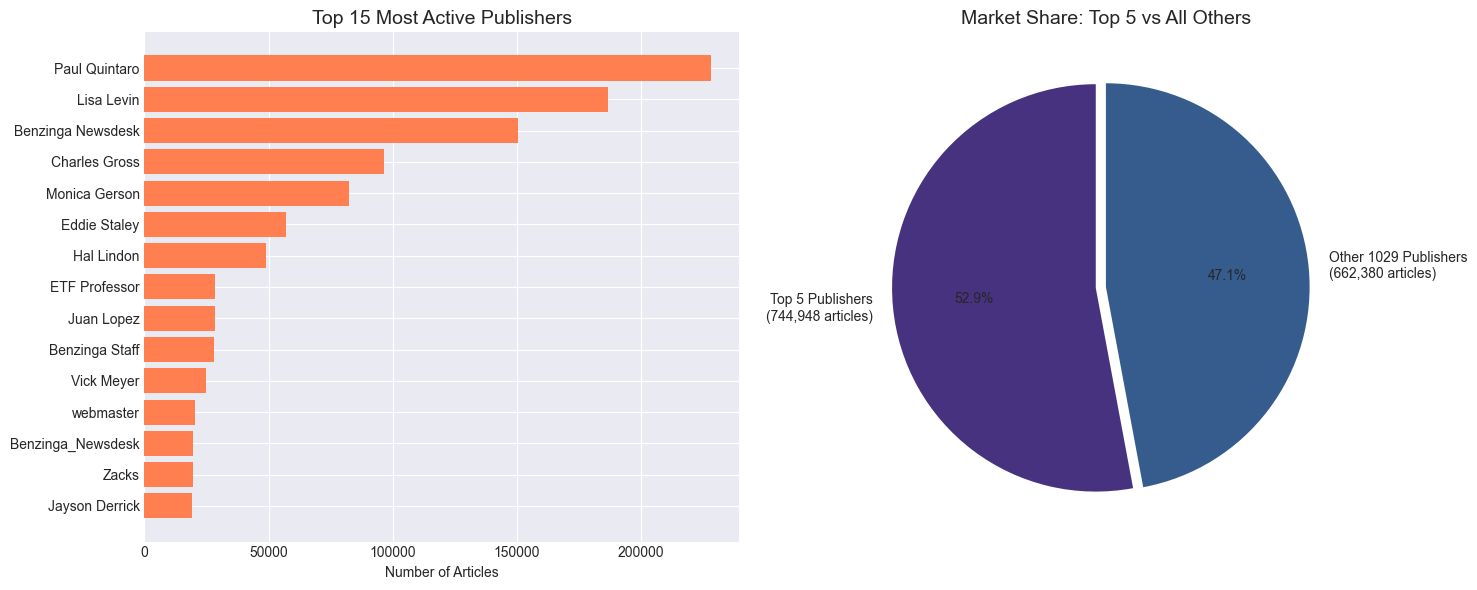

In [9]:
# Cell 5: Who publishes the most news
publisher_counts = df['publisher'].value_counts()

print("=== TOP 15 PUBLISHERS ===")
for i, (pub, count) in enumerate(publisher_counts.head(15).items(), 1):
    pct = (count / len(df)) * 100
    print(f"{i:2}. {pub[:40]:40} {count:8,} articles ({pct:.1f}%)")

print(f"\n📊 Total unique publishers: {df['publisher'].nunique():,}")
print(f"📊 Top publisher accounts for {publisher_counts.iloc[0]:,} articles ({publisher_counts.iloc[0]/len(df)*100:.1f}%)")

# Check for email addresses as publisher names
email_publishers = df[df['publisher'].str.contains('@', na=False)]['publisher'].nunique()
print(f"📧 Publishers with email addresses: {email_publishers}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 bar chart
top_pubs = publisher_counts.head(15)
axes[0].barh(range(len(top_pubs)), top_pubs.values, color='coral')
axes[0].set_yticks(range(len(top_pubs)))
axes[0].set_yticklabels([p[:30] for p in top_pubs.index])
axes[0].set_title('Top 15 Most Active Publishers', fontsize=14)
axes[0].set_xlabel('Number of Articles')
axes[0].invert_yaxis()

# Top 5 vs Others pie chart
top5_sum = publisher_counts.head(5).sum()
others_sum = publisher_counts[5:].sum()
pie_data = [top5_sum, others_sum]
pie_labels = [f'Top 5 Publishers\n({top5_sum:,} articles)', f'Other {len(publisher_counts)-5} Publishers\n({others_sum:,} articles)']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', explode=(0.05, 0), startangle=90)
axes[1].set_title('Market Share: Top 5 vs All Others', fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
# Cell 6: Process dates and times
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove any rows with invalid dates
initial_len = len(df)
df = df.dropna(subset=['date'])
print(f"Removed {initial_len - len(df):,} rows with invalid dates")

# Extract time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['date_only'] = df['date'].dt.date

print(f"\n📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"📅 Total days: {(df['date'].max() - df['date'].min()).days} days")

Removed 1,351,341 rows with invalid dates

📅 Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
📅 Total days: 3332 days


=== TIME SERIES STATISTICS ===
Average articles per day: 22.1
Median articles per day: 9.0
Max articles in a day: 973 on 2020-03-12
Min articles in a day: 1 on 2011-04-27

📈 TOP 5 BUSIEST DAYS:
   2020-03-12: 973 articles
   2020-06-05: 932 articles
   2020-06-10: 806 articles
   2020-06-09: 804 articles
   2020-06-08: 765 articles


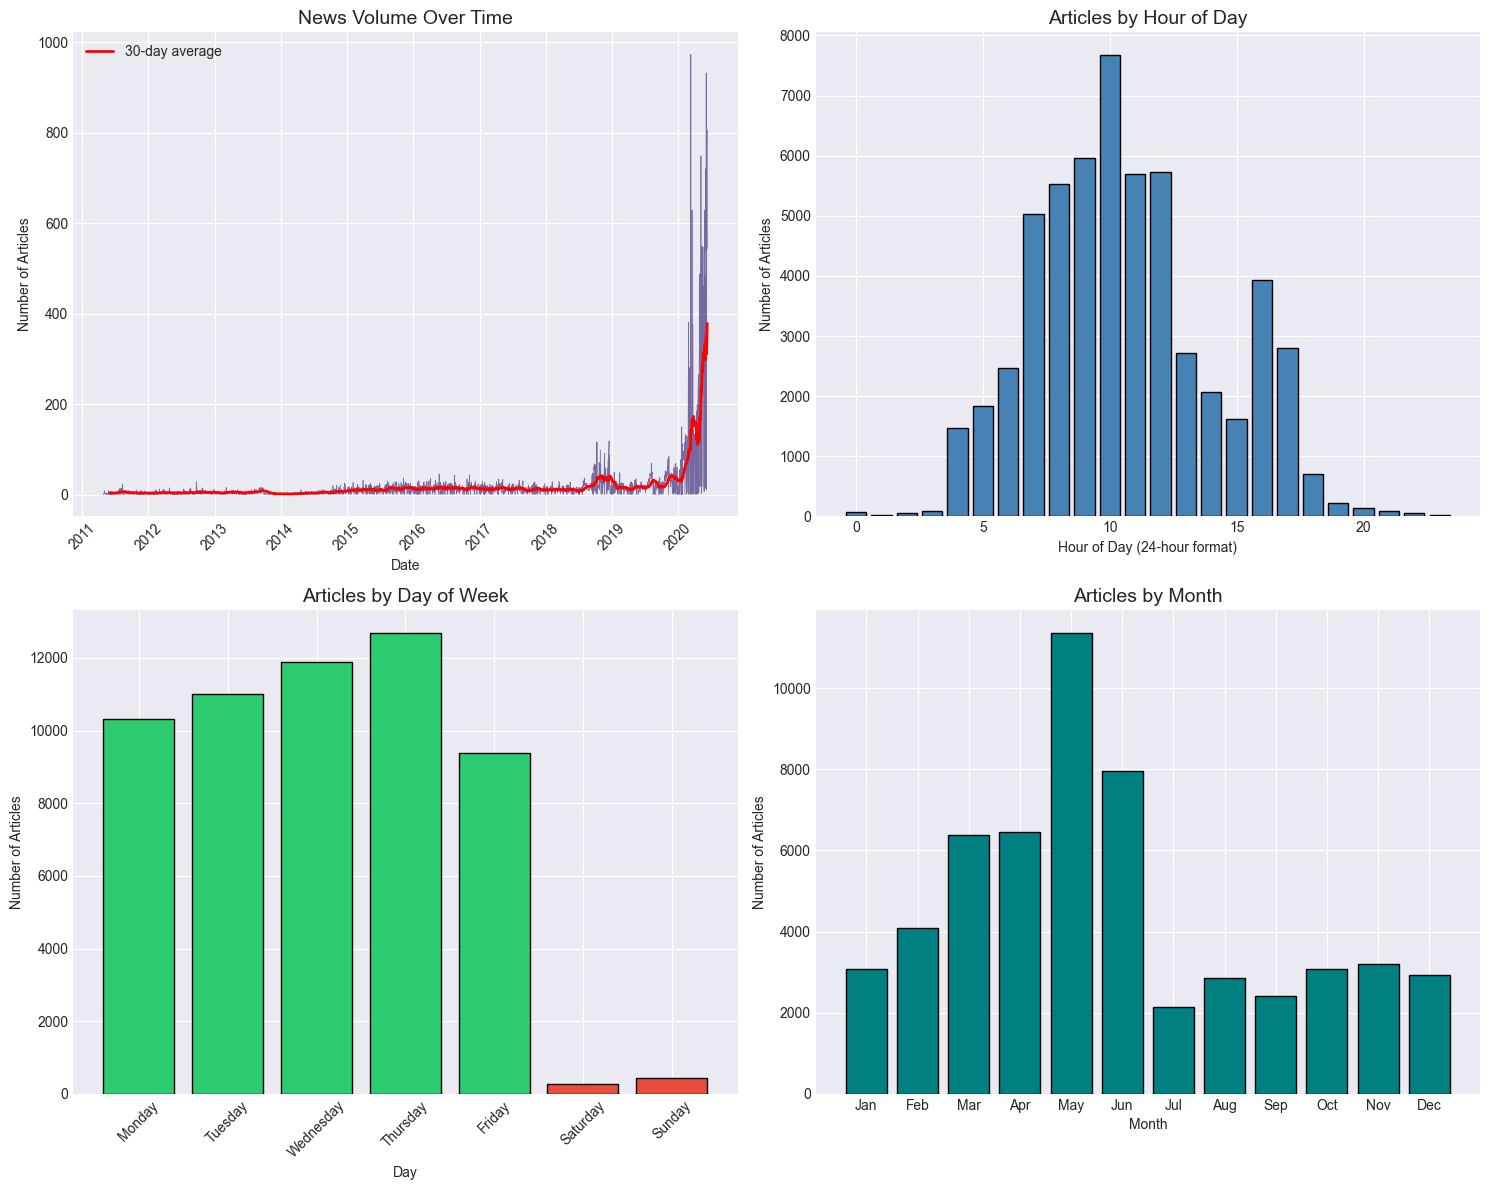

In [11]:
# Cell 7: News volume over time
daily_counts = df.groupby('date_only').size()

print("=== TIME SERIES STATISTICS ===")
print(f"Average articles per day: {daily_counts.mean():.1f}")
print(f"Median articles per day: {daily_counts.median():.1f}")
print(f"Max articles in a day: {daily_counts.max():,} on {daily_counts.idxmax()}")
print(f"Min articles in a day: {daily_counts.min():,} on {daily_counts.idxmin()}")

# Find top 5 busiest days
print(f"\n📈 TOP 5 BUSIEST DAYS:")
top_days = daily_counts.nlargest(5)
for date, count in top_days.items():
    print(f"   {date}: {count:,} articles")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Daily volume over time
axes[0,0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, alpha=0.7)
axes[0,0].set_title('News Volume Over Time', fontsize=14)
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Number of Articles')
axes[0,0].tick_params(axis='x', rotation=45)

# Rolling average (30-day)
rolling_avg = daily_counts.rolling(30).mean()
axes[0,0].plot(rolling_avg.index, rolling_avg.values, color='red', linewidth=2, label='30-day average')
axes[0,0].legend()

# Articles by hour
hour_counts = df['hour'].value_counts().sort_index()
axes[0,1].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black')
axes[0,1].set_title('Articles by Hour of Day', fontsize=14)
axes[0,1].set_xlabel('Hour of Day (24-hour format)')
axes[0,1].set_ylabel('Number of Articles')

# Articles by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts()
day_counts = day_counts.reindex(day_order)
colors_day = ['#2ecc71' if d in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] else '#e74c3c' for d in day_order]
axes[1,0].bar(day_counts.index, day_counts.values, color=colors_day, edgecolor='black')
axes[1,0].set_title('Articles by Day of Week', fontsize=14)
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Number of Articles')
axes[1,0].tick_params(axis='x', rotation=45)

# Articles by month
month_counts = df['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1,1].bar(month_names, month_counts.values, color='teal', edgecolor='black')
axes[1,1].set_title('Articles by Month', fontsize=14)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of Articles')

plt.tight_layout()
plt.show()

=== TOP 20 MOST MENTIONED STOCKS ===
 1. A              10 mentions (0.02%)
 2. AA             10 mentions (0.02%)
 3. AAC            10 mentions (0.02%)
 4. AAL            10 mentions (0.02%)
 5. AAMC           10 mentions (0.02%)
 6. AAME           10 mentions (0.02%)
 7. AAN            10 mentions (0.02%)
 8. AAOI           10 mentions (0.02%)
 9. AAON           10 mentions (0.02%)
10. AAP            10 mentions (0.02%)
11. AAPL           10 mentions (0.02%)
12. AAU            10 mentions (0.02%)
13. AAV            10 mentions (0.02%)
14. AAVL           10 mentions (0.02%)
15. AAWW           10 mentions (0.02%)
16. AB             10 mentions (0.02%)
17. ABAC           10 mentions (0.02%)
18. ABAX           10 mentions (0.02%)
19. ABB            10 mentions (0.02%)
20. ABBV           10 mentions (0.02%)

📊 Total unique stocks: 6,204
📊 Top stock: A (10 mentions)
📊 Top 10 stocks account for 0.2% of all mentions


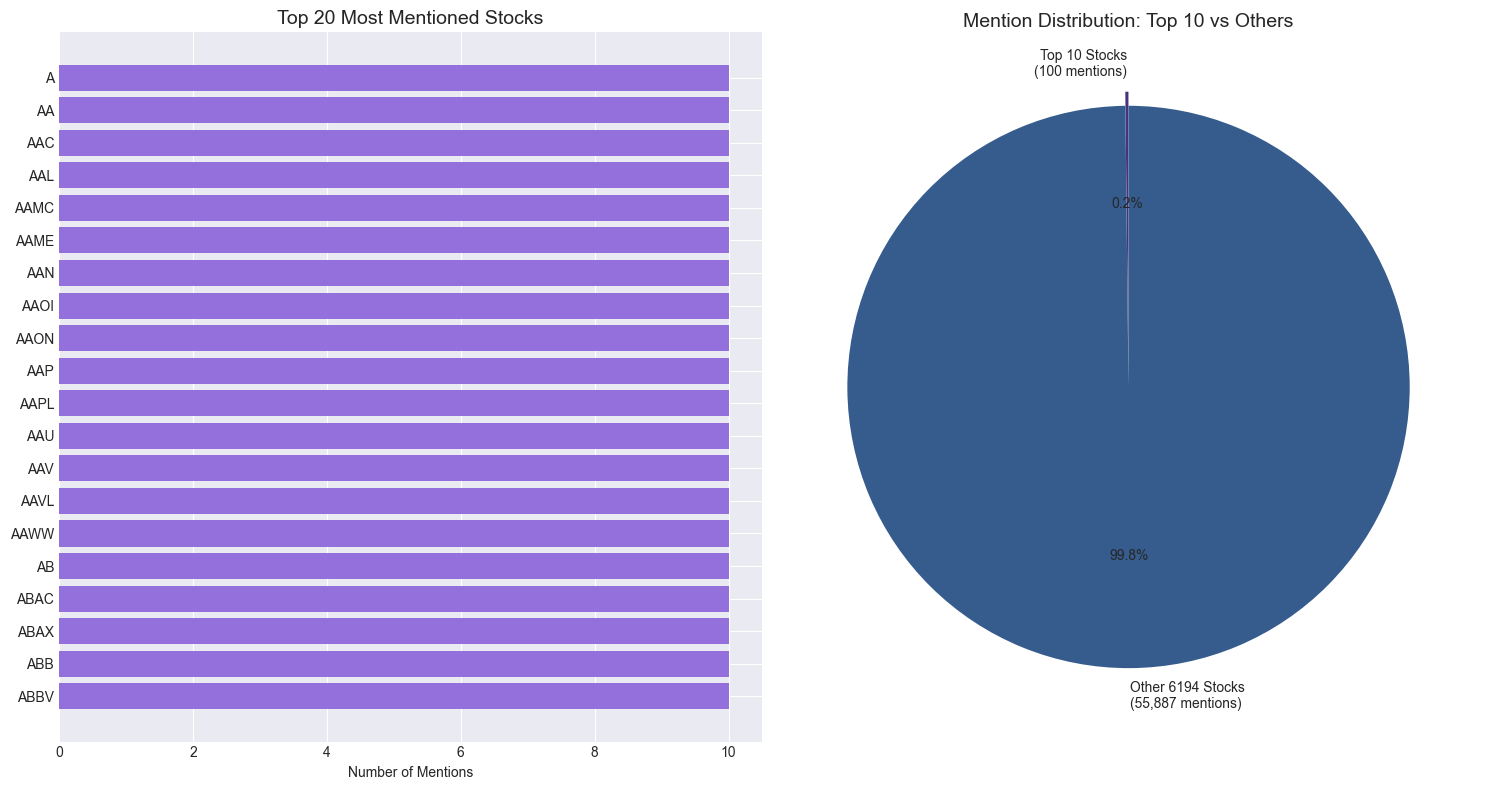

In [12]:
# Cell 8: Which stocks are mentioned most
stock_counts = df['stock'].value_counts()

print("=== TOP 20 MOST MENTIONED STOCKS ===")
for i, (stock, count) in enumerate(stock_counts.head(20).items(), 1):
    pct = (count / len(df)) * 100
    print(f"{i:2}. {stock:8} {count:8,} mentions ({pct:.2f}%)")

print(f"\n📊 Total unique stocks: {df['stock'].nunique():,}")
print(f"📊 Top stock: {stock_counts.index[0]} ({stock_counts.iloc[0]:,} mentions)")
print(f"📊 Top 10 stocks account for {stock_counts.head(10).sum() / len(df) * 100:.1f}% of all mentions")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Top 20 bar chart
top_stocks = stock_counts.head(20)
axes[0].barh(range(len(top_stocks)), top_stocks.values, color='mediumpurple')
axes[0].set_yticks(range(len(top_stocks)))
axes[0].set_yticklabels(top_stocks.index)
axes[0].set_title('Top 20 Most Mentioned Stocks', fontsize=14)
axes[0].set_xlabel('Number of Mentions')
axes[0].invert_yaxis()

# Top 10 vs Others pie chart
top10_sum = stock_counts.head(10).sum()
others_sum = stock_counts[10:].sum()
pie_data = [top10_sum, others_sum]
pie_labels = [f'Top 10 Stocks\n({top10_sum:,} mentions)', f'Other {len(stock_counts)-10} Stocks\n({others_sum:,} mentions)']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', explode=(0.05, 0), startangle=90)
axes[1].set_title('Mention Distribution: Top 10 vs Others', fontsize=14)

plt.tight_layout()
plt.show()

Using 55,987 articles for keyword analysis
=== TOP 30 KEYWORDS/BIGRAMS (TF-IDF) ===
 1. target                    score: 2889.0934
 2. week                      score: 2809.4937
 3. 52                        score: 2572.7433
 4. etfs                      score: 2561.6659
 5. 52 week                   score: 2514.0681
 6. trading                   score: 2388.5081
 7. eps                       score: 2264.1418
 8. reports                   score: 2169.0201
 9. maintains                 score: 2135.3581
10. hit                       score: 2109.5653
11. hit 52                    score: 2070.8540
12. as                        score: 1928.1283
13. announces                 score: 1868.6496
14. earnings                  score: 1827.7341
15. session                   score: 1810.3885
16. sales                     score: 1810.0126
17. estimate                  score: 1729.6172
18. moving                    score: 1690.2464
19. higher                    score: 1647.0831
20. mid                

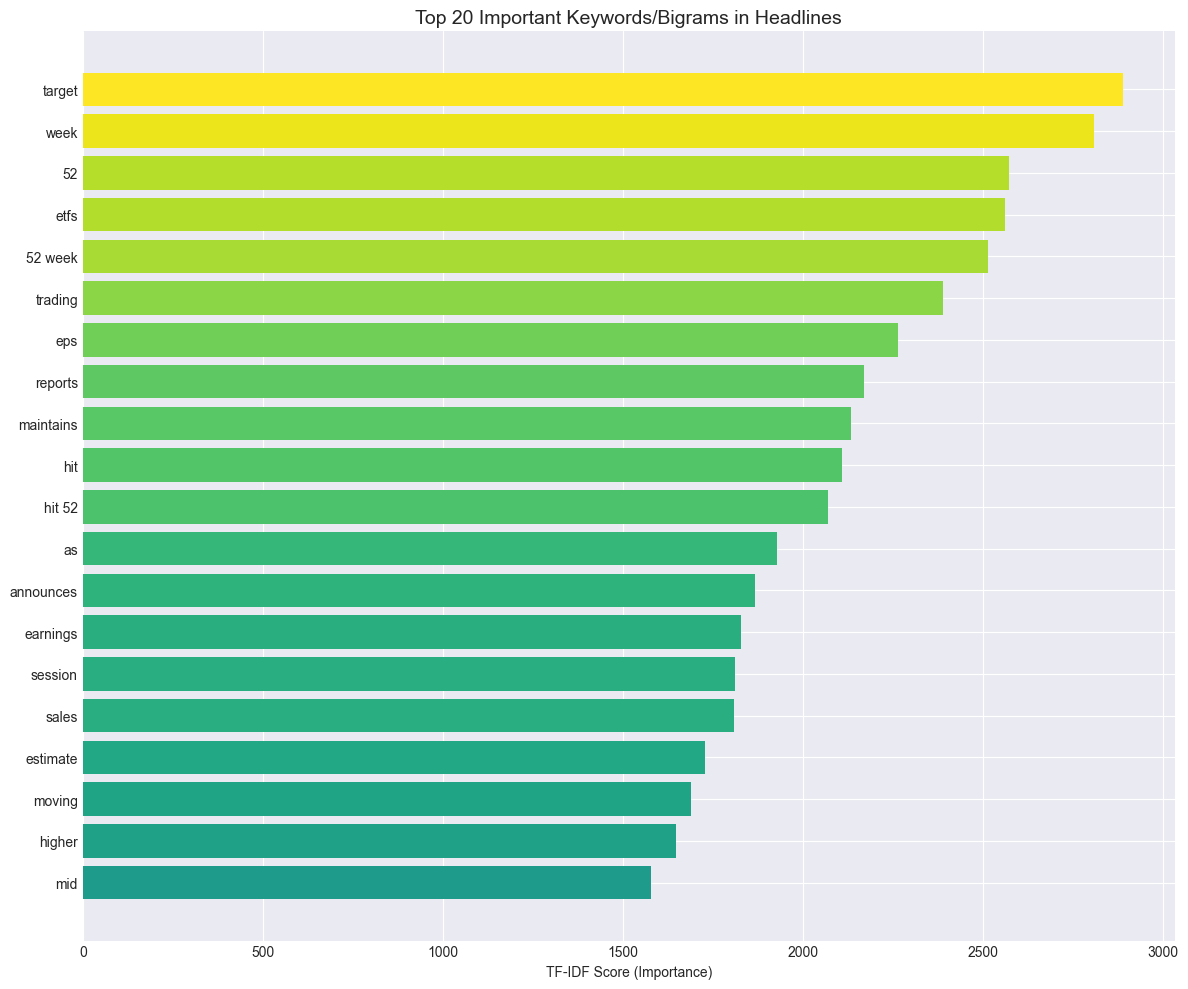

In [13]:
# Cell 9: Extract important keywords
from sklearn.feature_extraction.text import TfidfVectorizer

# Define stop words (common words to ignore)
stop_words = ['the', 'a', 'an', 'and', 'or', 'but', 'for', 'of', 'to', 'in', 
              'on', 'at', 'by', 'with', 'without', 'is', 'are', 'was', 'were',
              'be', 'been', 'being', 'have', 'has', 'had', 'having', 'from',
              'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further',
              'then', 'once', 'here', 'there', 'all', 'any', 'both', 'each',
              'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor',
              'not', 'only', 'own', 'same', 'so', 'than', 'that', 'these',
              'those', 'through', 'until', 'unto', 'very', 'just', 'but',
              'does', 'doing', 'their', 'they', 'we', 'our', 'you', 'your',
              'stock', 'shares', 'market', 'company', 'stocks', 'share', 'price']

# Sample a subset for faster processing (use 100k articles)
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
print(f"Using {sample_size:,} articles for keyword analysis")

# Create TF-IDF vectors
tfidf = TfidfVectorizer(max_features=50, stop_words=stop_words, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df_sample['headline'].fillna(''))

# Get feature names and scores
feature_names = tfidf.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray().sum(axis=0)

# Create DataFrame with keywords and scores
keyword_df = pd.DataFrame({'keyword': feature_names, 'tfidf_score': tfidf_scores})
keyword_df = keyword_df.sort_values('tfidf_score', ascending=False)

print("=== TOP 30 KEYWORDS/BIGRAMS (TF-IDF) ===")
for i, (_, row) in enumerate(keyword_df.head(30).iterrows(), 1):
    print(f"{i:2}. {row['keyword']:25} score: {row['tfidf_score']:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
top_keywords = keyword_df.head(20)
colors = plt.cm.viridis(top_keywords['tfidf_score'].values / top_keywords['tfidf_score'].max())
ax.barh(range(len(top_keywords)), top_keywords['tfidf_score'].values, color=colors)
ax.set_yticks(range(len(top_keywords)))
ax.set_yticklabels(top_keywords['keyword'].values)
ax.set_title('Top 20 Important Keywords/Bigrams in Headlines', fontsize=14)
ax.set_xlabel('TF-IDF Score (Importance)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

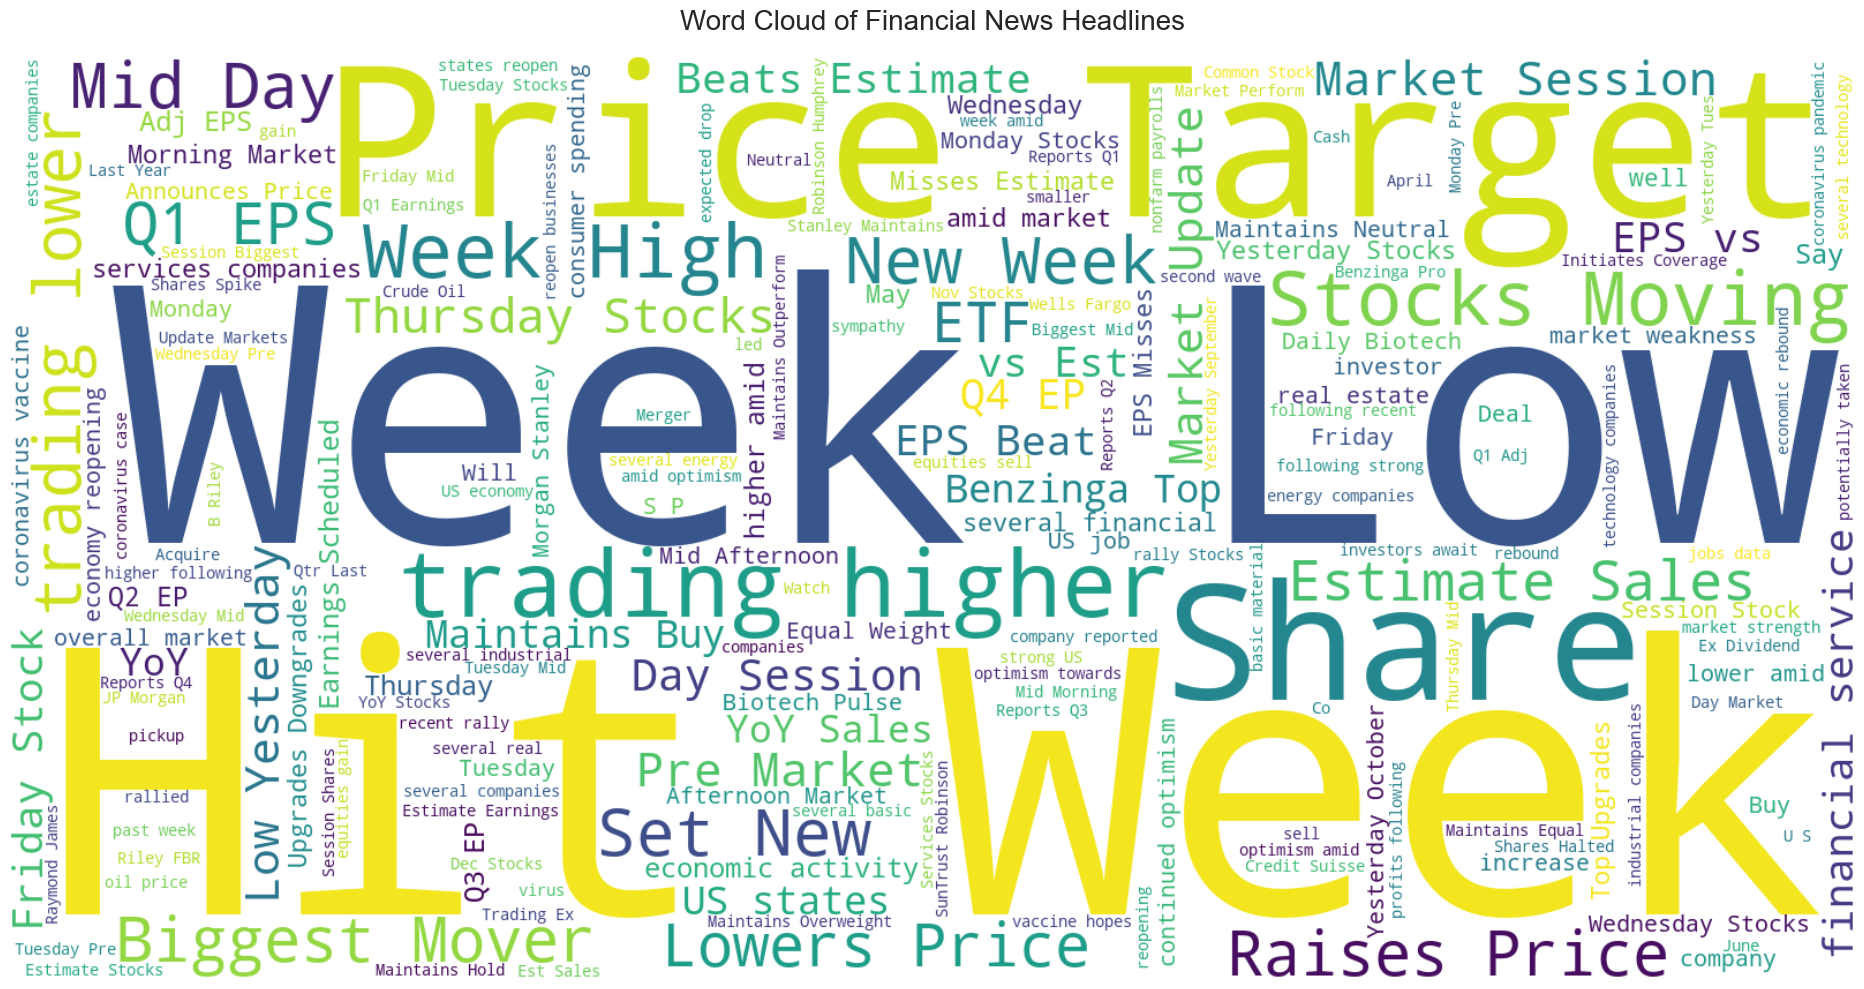

In [14]:
# Cell 10: Create a word cloud
from wordcloud import WordCloud

# Generate word cloud from all headlines
all_text = ' '.join(df['headline'].fillna('').astype(str))

wordcloud = WordCloud(width=1600, height=800, background_color='white', 
                     max_words=200, colormap='viridis', 
                     contour_width=1, contour_color='steelblue').generate(all_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Financial News Headlines', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [15]:
# Cell 11: Discover hidden topics
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Use sample for LDA (smaller sample needed)
lda_sample_size = min(50000, len(df))
df_lda = df.sample(n=lda_sample_size, random_state=42)

# Create document-term matrix
vectorizer = CountVectorizer(max_features=100, stop_words=stop_words, 
                            max_df=0.8, min_df=10)
dtm = vectorizer.fit_transform(df_lda['headline'].fillna(''))

# Apply LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=100)
lda.fit(dtm)

# Display topics
feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_top_words=12):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        topics[f"Topic {topic_idx+1}"] = top_words
    return topics

topics = display_topics(lda, feature_names, 12)

print("="*60)
print("TOP 5 THEMES DISCOVERED IN FINANCIAL HEADLINES")
print("="*60)
for topic, words in topics.items():
    print(f"\n{topic}:")
    print(f"  → {' → '.join(words)}")

TOP 5 THEMES DISCOVERED IN FINANCIAL HEADLINES

Topic 1:
  → earnings → update → reports → mid → will → says → co → 2020 → its → markets → group → may

Topic 2:
  → eps → sales → estimate → vs → q1 → yoy → raises → downgrades → est → benzinga → top → reports

Topic 3:
  → trading → as → companies → several → higher → us → amid → lower → following → coronavirus → economic → optimism

Topic 4:
  → target → maintains → session → moving → etfs → lowers → buy → announces → etf → day → mid → pre

Topic 5:
  → week → 52 → hit → lows → new → yesterday → highs → thursday → biggest → set → which → movers


In [16]:
# Cell 12: Final summary of findings
print("="*60)
print("TASK 1 - EXPLORATORY DATA ANALYSIS: FINAL SUMMARY")
print("="*60)

print(f"\n DATASET OVERVIEW:")
print(f"   • Total articles analyzed: {len(df):,}")
print(f"   • Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   • Unique stocks mentioned: {df['stock'].nunique():,}")
print(f"   • Unique publishers: {df['publisher'].nunique():,}")

print(f"\n HEADLINE STATISTICS:")
print(f"   • Average length: {df['headline_length'].mean():.1f} characters")
print(f"   • Average word count: {df['word_count'].mean():.1f} words")
print(f"   • Most common length range: {df['headline_length'].quantile(0.25):.0f}-{df['headline_length'].quantile(0.75):.0f} chars")

print(f"\n TOP PUBLISHERS:")
top3 = df['publisher'].value_counts().head(3)
for pub, count in top3.items():
    print(f"   • {pub[:35]}: {count:,} articles ({count/len(df)*100:.1f}%)")

print(f"\n TEMPORAL PATTERNS:")
print(f"   • Most active hour: {df['hour'].mode()[0]}:00 ({df[df['hour']==df['hour'].mode()[0]].shape[0]:,} articles)")
print(f"   • Most active day: {df['day_of_week'].mode()[0]}")
print(f"   • Most active month: {month_names[df['month'].mode()[0]-1]}")

print(f"\n MOST MENTIONED STOCKS:")
top5_stocks = df['stock'].value_counts().head(5)
for stock, count in top5_stocks.items():
    print(f"   • {stock}: {count:,} mentions ({count/len(df)*100:.2f}%)")

print(f"\n TOP KEYWORDS:")
top5_keywords = keyword_df.head(5)['keyword'].tolist()
print(f"   • {', '.join(top5_keywords)}")

print("\n" + "="*60)
print("TASK 1 COMPLETED SUCCESSFULLY!")
print("="*60)

TASK 1 - EXPLORATORY DATA ANALYSIS: FINAL SUMMARY

 DATASET OVERVIEW:
   • Total articles analyzed: 55,987
   • Date range: 2011-04-27 to 2020-06-11
   • Unique stocks mentioned: 6,204
   • Unique publishers: 225

 HEADLINE STATISTICS:
   • Average length: 80.0 characters
   • Average word count: 12.4 words
   • Most common length range: 42-91 chars

 TOP PUBLISHERS:
   • Benzinga Newsdesk: 14,750 articles (26.3%)
   • Lisa Levin: 12,408 articles (22.2%)
   • ETF Professor: 4,362 articles (7.8%)

 TEMPORAL PATTERNS:
   • Most active hour: 10:00 (7,669 articles)
   • Most active day: Thursday
   • Most active month: May

 MOST MENTIONED STOCKS:
   • A: 10 mentions (0.02%)
   • AA: 10 mentions (0.02%)
   • AAC: 10 mentions (0.02%)
   • AAL: 10 mentions (0.02%)
   • AAMC: 10 mentions (0.02%)

 TOP KEYWORDS:
   • target, week, 52, etfs, 52 week

TASK 1 COMPLETED SUCCESSFULLY!


In [17]:
# Cell 13: Save processed data for later tasks
# Save the processed dataframe with new columns
df.to_csv('../data/processed_news.csv', index=False)
print(" Processed data saved to: ../data/processed_news.csv")

# Save summary statistics to a text file
with open('../reports/task1_summary.txt', 'w') as f:
    f.write("TASK 1 - EDA SUMMARY\n")
    f.write("="*50 + "\n")
    f.write(f"Total articles: {len(df):,}\n")
    f.write(f"Date range: {df['date'].min()} to {df['date'].max()}\n")
    f.write(f"Unique stocks: {df['stock'].nunique():,}\n")
    f.write(f"Unique publishers: {df['publisher'].nunique():,}\n")
    f.write(f"Average headline length: {df['headline_length'].mean():.1f} chars\n")
    
print(" Summary saved to: ../reports/task1_summary.txt")

 Processed data saved to: ../data/processed_news.csv


FileNotFoundError: [Errno 2] No such file or directory: '../reports/task1_summary.txt'